# Cinema-an movie recommender

This is my final project for class. I wanted a movie recommendation model where I could input a single or multiple movies and get a list of recommendations that would make sense.

The main reason I wanted to do this project is because I use a streaming app called "Stremio" to watch my movies. It allows for 3rd party plugins but nothing really recommends movies using machine learning or AI.

How it works:
1. I list my favorite movies
2. The model grabs plot, cast, keywords, and director from TMDb
3. NLP figures out what those movies have in common
4. It also looks at MovieLens ratings to find users with similar taste to me
5. It mixes both signals to recommend movies I havent seen, with confidence ratings

This notebook is self-contained. Everything is already trained and saved in cinema_artifacts.pkl so you dont need to download MovieLens or wait for training. Just hit Run All.


In [1]:
import pickle, gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import linear_kernel

import warnings
warnings.filterwarnings('ignore')

# load my saved Model (compressed to fit on github)
with gzip.open('cinema_artifacts.pkl.gz', 'rb') as f:
    Model = pickle.load(f)

# item_factors and item_bias were saved as float16 to save space, cast back to float32 for math
Model['item_factors'] = Model['item_factors'].astype(np.float32)
Model['item_bias'] = Model['item_bias'].astype(np.float32)

print("loaded.")
print("tfidf shape:", Model['tfidf_matrix'].shape)
print("trained on", Model['data_sample_size'], "ratings")
print(len(Model['top_recs']), "recommendations ready")


loaded.
tfidf shape: (61436, 49894)
trained on 20000000 ratings
15 recommendations ready


## My favorite movies

These are the 20 movies I gave the model. The recommender uses them as the starting point to figure out what to suggest.


In [2]:
Watched = Model['watched_df']
print("my", len(Watched), "favorites:\n")
print(Watched[['title', 'year']].to_string(index=False))


my 20 favorites:

                                            title  year
                                        Inception  2010
                                  The Dark Knight  2008
                                     Interstellar  2014
                                       The Matrix  1999
                                     Pulp Fiction  1994
                                       Fight Club  1999
The Lord of the Rings: The Fellowship of the Ring  2001
                                       GoodFellas  1990
            Eternal Sunshine of the Spotless Mind  2004
                               The Social Network  2010
                                         Whiplash  2014
                                         Parasite  2019
                           No Country for Old Men  2007
                              There Will Be Blood  2007
                                    Spirited Away  2001
                               Mad Max: Fury Road  2015
                              

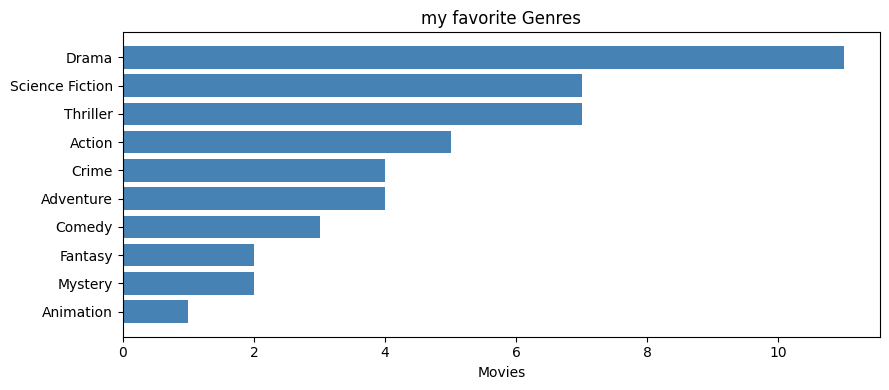

In [3]:
# bar chart of my top Genres
Genres = pd.Series(Model['user_genre_counts']).head(10)

plt.figure(figsize=(9, 4))
plt.barh(Genres.index[::-1], Genres.values[::-1], color='steelblue')
plt.xlabel('Movies')
plt.title('my favorite Genres')
plt.tight_layout()
plt.show()


## The MovieLens dataset

I trained the collaborative filtering side on MovieLens 25M. Its a public dataset on kaggle with 25 million movie ratings from 162,000 users covering around 60,000 movies. The charts below show what it looks like.


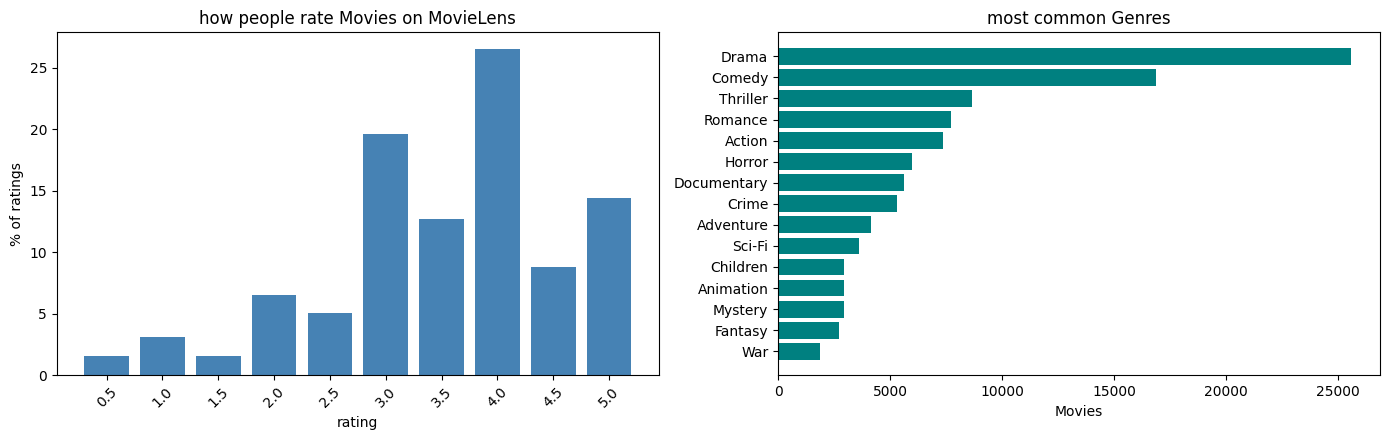

total ratings: 25000095
total Movies: 62423


In [4]:
RatingsDist = pd.Series(Model['movielens_rating_dist']).sort_index()
TopGenres = pd.Series(Model['movielens_genre_top'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(RatingsDist.index.astype(str), RatingsDist.values * 100, color='steelblue')
axes[0].set_xlabel('rating')
axes[0].set_ylabel('% of ratings')
axes[0].set_title('how people rate Movies on MovieLens')
axes[0].tick_params(axis='x', rotation=45)

axes[1].barh(TopGenres.index[::-1], TopGenres.values[::-1], color='teal')
axes[1].set_xlabel('Movies')
axes[1].set_title('most common Genres')

plt.tight_layout()
plt.show()

print("total ratings:", Model['data_total_ratings'])
print("total Movies:", Model['data_total_movies'])


## How NLP finds similar movies (TF-IDF)

This is the NLP half of the model.

I used a method called Term Frequency Inverse Document Frequency (TF-IDF). Its a standard NLP technique that turns text into numbers.

For each movie I take its plot, keywords, cast, and director and combine them into one big text string. TF-IDF reads through every movies string and gives each word a score. Words that show up a lot in one movie but rarely in others get high scores. Common words like "the" or "and" get low scores because they show up everywhere. Words like "spaceship" or "samurai" or "Nolan" get high scores because they distinguish movies from each other.

The result is a 61,000 x 49,000 sparse matrix where rows are movies and columns are words.

To compare two movies I use cosine similarity. It lines up two movies score lists and checks how well the high scores match. The result is between 0 and 1 where higher means more similar. I picked cosine because it ignores text length, so a movie with a really long plot summary doesnt have an edge over one with a short summary.

The cell below picks a movie and finds the most similar ones.


In [5]:
def find_similar(name, top_n=10):
    df = Model['corpus_df']
    hits = df[df['title'].str.contains(name, case=False, na=False)]
    if len(hits) == 0:
        print("nothing matched", name)
        return
    i = Model['movie_uid_to_idx'][hits.iloc[0]['uid']]
    sims = linear_kernel(Model['tfidf_matrix'][i], Model['tfidf_matrix']).flatten()
    top = np.argsort(sims)[::-1][1:top_n+1]
    return pd.DataFrame({
        'title': df['title'].iloc[top].values,
        'similarity': sims[top],
    })


# try it on a movie from my favorites
Result = find_similar("Inception")
print("most similar to Inception:\n")
print(Result.to_string(index=False))


most similar to Inception:

                                                          title  similarity
                                  Jurassic World Rebirth (2025)    0.171929
                                      Predator: Badlands (2025)    0.156622
                                             Matrix, The (1999)    0.155985
                                    Subconscious Cruelty (2000)    0.154612
                                         Science Fiction (2002)    0.154460
                                          Without Memory (1996)    0.153067
                                    Dream the Impossible (2017)    0.146702
                                         Once Upon a Spy (1980)    0.142081
                                        A Dream of Kings (1969)    0.139527
Monsters, Madmen & Machines: 25 Years of Science Fiction (1984)    0.139220


## How collaborative filtering works (SVD)

The other half of the model uses ratings instead of text.

The way it works is if a bunch of MovieLens users rated my favorite movies highly, their taste is probably similar to mine. Whatever else they liked, Id probably like too.

I take the giant ratings table (162,000 users by 56,000 movies, mostly empty since not every user rated every movie) and use Singular Value Decomposition (SVD) to compress it. SVD finds 150 hidden taste dimensions. Every user becomes a vector of 150 numbers and every movie also becomes 150 numbers. The model figures out what those dimensions mean on its own. They probably end up capturing things like "loves sci-fi" or "hates horror".

The chart shows how much info each of the 150 dimensions adds. By dimension 150 it has captured around 24% of the patterns in the ratings.


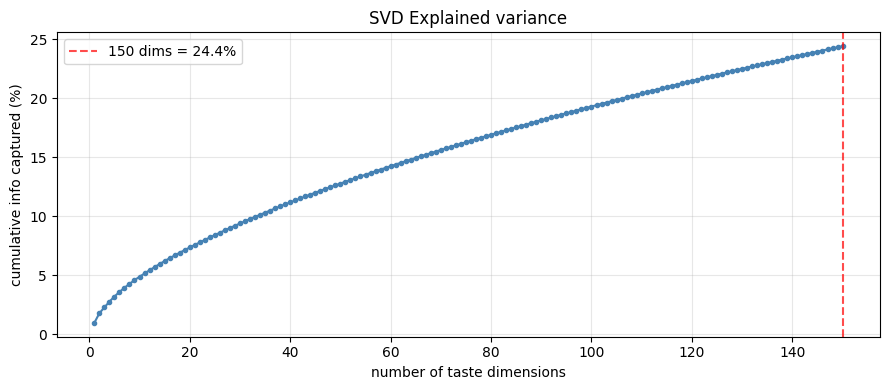

In [6]:
# elbow plot, how much info each dimension adds
Explained = Model['explained_variance'].cumsum()
n = Model['n_components']

plt.figure(figsize=(9, 4))
plt.plot(range(1, n+1), Explained * 100, marker='o', markersize=3, color='steelblue')
plt.axvline(n, color='red', linestyle='--', alpha=0.7,
            label=f'{n} dims = {Explained[-1]*100:.1f}%')
plt.xlabel('number of taste dimensions')
plt.ylabel('cumulative info captured (%)')
plt.title('SVD Explained variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## The recommendations

The model blends both halves (text similarity + similar users) 50/50 into a hybrid score with a confidence rating.

High = both signals strongly agree, trust this one.
Medium = pretty confident, decent pick.
Low = only one signal supports it.

Movies marked with * are recent releases that arent in the MovieLens dataset, so I only have plot data on them and no rating data. They get capped at Medium since the model cant be more confident without rating evidence.


In [7]:
Recs = Model['top_recs']

for _, row in Recs.iterrows():
    star = '*' if row['source'] == 'tmdb_new' else ' '
    print(f"{row['rank']:2}. {star}{row['title'][:42]:<43} {row['hybrid_score']:.0%}  ({row['confidence_label']})")

print("\n* = recent release, not in MovieLens")


 1.  Schindler's List (1993)                     55%  (Medium)
 2. *Dune: Part Two (2024)                       50%  (Medium)
 3. *Project Hail Mary (2026)                    49%  (Medium)
 4. *Good Luck, Have Fun, Don't Die (2026)       47%  (Medium)
 5.  Godfather, The (1972)                       47%  (Medium)
 6. *The Running Man (2025)                      46%  (Medium)
 7. *Mercy (2026)                                46%  (Medium)
 8.  Planet Earth (2006)                         45%  (Medium)
 9.  Star Wars: Episode V - The Empire Strikes   44%  (High)
10.  Band of Brothers (2001)                     43%  (Medium)
11. *One Battle After Another (2025)             43%  (Medium)
12.  Planet Earth II (2016)                      43%  (Medium)
13.  Alien (1979)                                42%  (High)
14. *Josee, the Tiger and the Fish (2020)        42%  (Medium)
15. *Spider-Man: Across the Spider-Verse (2023)  39%  (Medium)

* = recent release, not in MovieLens


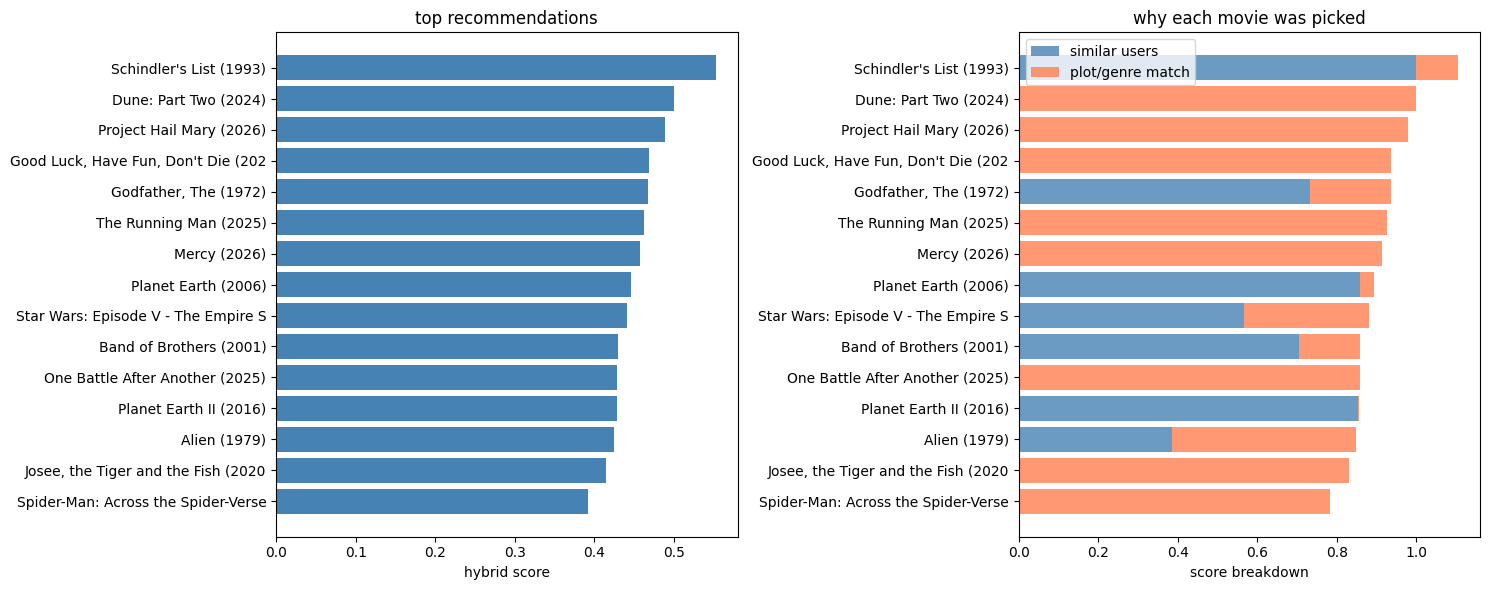

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ShortTitles = Recs['title'].str[:35]

# left side, just the hybrid score
axes[0].barh(ShortTitles[::-1], Recs['hybrid_score'][::-1], color='steelblue')
axes[0].set_xlabel('hybrid score')
axes[0].set_title('top recommendations')

# right side, stacked to show why
axes[1].barh(ShortTitles[::-1], Recs['cf_score'][::-1],
             label='similar users', color='steelblue', alpha=0.8)
axes[1].barh(ShortTitles[::-1], Recs['content_score'][::-1],
             left=Recs['cf_score'][::-1],
             label='plot/genre match', color='coral', alpha=0.8)
axes[1].set_xlabel('score breakdown')
axes[1].set_title('why each movie was picked')
axes[1].legend()

plt.tight_layout()
plt.show()


## How I tested it

To make sure the model is actually learning, I held out 20% of the MovieLens ratings during training and used them as a test set. The model never saw these.

Then I had it predict those held-out ratings and measured RMSE (basically the average error in stars). Lower is better.

I compared against three baselines to prove its actually working:
1. Always predict the global average rating
2. Always predict each users average
3. Use per-user and per-movie averages with no SVD

The model has to beat all three to prove its actually learning taste patterns.


In [9]:
# RMSE = average error in stars, lower is better
print("baselines vs my Model:\n")
print(f"  global mean baseline:    {Model['rmse_global_baseline']:.4f}")
print(f"  per-user mean baseline:  {Model['rmse_user_baseline']:.4f}")
print(f"  user+movie avg baseline: {Model['rmse_bias_only']:.4f}")
print(f"  full Model:              {Model['rmse_full_svd']:.4f}")

Beat = Model['rmse_user_baseline'] - Model['rmse_full_svd']
print(f"\nmy Model beats per-user baseline by {Beat:.4f} stars")
print("so its actually learning, not just averaging")


baselines vs my Model:

  global mean baseline:    1.0607
  per-user mean baseline:  0.9572
  user+movie avg baseline: 0.8768
  full Model:              0.8511

my Model beats per-user baseline by 0.1061 stars
so its actually learning, not just averaging


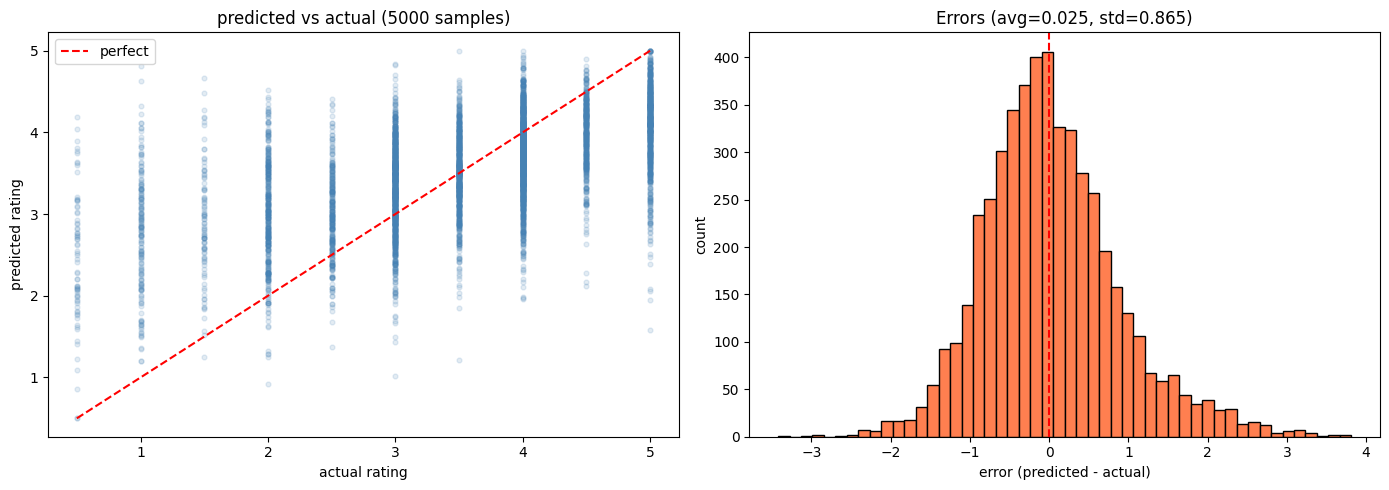

In [10]:
YTrue = Model['eval_y_true_sample']
YPred = Model['eval_y_pred_sample']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# scatter, perfect predictions sit on the red line
axes[0].scatter(YTrue, YPred, alpha=0.15, s=12, color='steelblue')
axes[0].plot([0.5, 5.0], [0.5, 5.0], 'r--', label='perfect')
axes[0].set_xlabel('actual rating')
axes[0].set_ylabel('predicted rating')
axes[0].set_title(f'predicted vs actual ({len(YTrue)} samples)')
axes[0].legend()

# error histogram
Errors = YPred - YTrue
axes[1].hist(Errors, bins=50, color='coral', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('error (predicted - actual)')
axes[1].set_ylabel('count')
axes[1].set_title(f'Errors (avg={Errors.mean():.3f}, std={Errors.std():.3f})')

plt.tight_layout()
plt.show()


## Recap

What I built: a movie recommender that mixes two approaches.

NLP side. Each movies plot, keywords, cast, and director get turned into one big text string. Run TF-IDF to get word scores per movie. Compare with cosine similarity. Movies with similar word patterns are similar movies.

Collaborative filtering side. SVD compresses 25 million ratings into 150 hidden taste dimensions per user and per movie. Find MovieLens users who rated my favorites highly (proxy users), average their taste vectors, use that to score every other movie.

Hybrid. Mix both 50/50 into a final score with a confidence rating based on whether both halves agree.

Results. RMSE of 0.85 stars on the test set, beating all three baselines. So the model is actually learning taste, not just predicting averages.


## Try it on a single movie

The model also works with just one movie as input instead of a full favorites list. Type a movie name in the cell below and run it. The recommendations end up much tighter and the confidence ratings end up much higher because the model can lock onto one specific taste pattern instead of averaging across a bunch of different genres.


In [11]:
# build the single-movie recommender. run this cell once.
import re

PopularSet = set(Model['popular_ml_ids'])

# normalize item_factors so dot products give cosine similarity
TasteVectors = Model['item_factors']
TasteNorm = TasteVectors / (np.linalg.norm(TasteVectors, axis=1, keepdims=True) + 1e-9)

# precompute a normalized title for each movie in the corpus, so we can search
# without worrying about "The Matrix" vs "Matrix, The (1999)" etc.
def normalize_title(t):
    t = re.sub(r'\s*\(\d{4}\)\s*$', '', str(t))   # drop year
    t = re.sub(r',\s*(The|A|An)\s*$', '', t, flags=re.I)  # "Matrix, The" -> "Matrix"
    t = re.sub(r'^(The|A|An)\s+', '', t, flags=re.I)  # "The Matrix" -> "Matrix"
    return t.lower().strip()

Movies = Model['corpus_df'].copy()
Movies['title_norm'] = Movies['title'].apply(normalize_title)


def find_movie_uid(name):
    Query = normalize_title(name)
    # 1. exact match
    exact = Movies[Movies['title_norm'] == Query]
    if len(exact) > 0:
        # if multiple, pick the popular one
        in_pop = exact['movielens_id'].apply(lambda x: pd.notna(x) and int(x) in PopularSet)
        if in_pop.any():
            return exact[in_pop].iloc[0]
        return exact.iloc[0]
    # 2. exact starts-with (e.g. "matrix" matches "matrix reloaded" too, take the popular one)
    starts = Movies[Movies['title_norm'].str.startswith(Query)]
    if len(starts) > 0:
        in_pop = starts['movielens_id'].apply(lambda x: pd.notna(x) and int(x) in PopularSet)
        if in_pop.any():
            return starts[in_pop].iloc[0]
        return starts.iloc[0]
    # 3. substring match, prefer popular ones
    subs = Movies[Movies['title'].str.contains(name, case=False, na=False, regex=False)]
    if len(subs) == 0:
        return None
    in_pop = subs['movielens_id'].apply(lambda x: pd.notna(x) and int(x) in PopularSet)
    if in_pop.any():
        return subs[in_pop].iloc[0]
    return subs.iloc[0]


def recommend_from_one(movie_name, top_n=15, cf_weight=0.5, content_weight=0.5):
    target = find_movie_uid(movie_name)
    if target is None:
        print("nothing matched", movie_name)
        return None
    print(f"using: {target['title']}")

    target_uid = target['uid']
    target_idx = Model['movie_uid_to_idx'][target_uid]

    # content scores: cosine similarity on TF-IDF
    sims_content = linear_kernel(Model['tfidf_matrix'][target_idx], Model['tfidf_matrix']).flatten()

    # CF scores: cosine similarity on item_factors (only if input is in MovieLens)
    sims_cf = np.zeros(len(Movies))
    target_ml = target.get('movielens_id')
    has_cf = pd.notna(target_ml) and int(target_ml) in Model['movie_to_idx']

    if has_cf:
        target_col = Model['movie_to_idx'][int(target_ml)]
        cf_sim_all = TasteNorm @ TasteNorm[target_col]
        # map MovieLens column index -> corpus row
        ml_to_corpus = {}
        for i, ml in enumerate(Movies['movielens_id'].values):
            if pd.notna(ml) and int(ml) in Model['movie_to_idx']:
                ml_to_corpus[Model['movie_to_idx'][int(ml)]] = i
        for col_idx, corpus_idx in ml_to_corpus.items():
            sims_cf[corpus_idx] = cf_sim_all[col_idx]
    else:
        print("(this movie isnt in MovieLens, using text similarity only)")

    # build candidate dataframe
    Candidates = Movies.copy()
    Candidates['content_raw'] = sims_content
    Candidates['cf_raw'] = sims_cf
    Candidates = Candidates[Candidates['uid'] != target_uid]
    # also drop Movies already on the favorites list (already Watched)
    watched_tmdb = set(Model['watched_df']['tmdb_id'].dropna().astype(int))
    Candidates = Candidates[~Candidates['tmdb_id'].isin(watched_tmdb)]

    # filter to popular MovieLens Movies + recent TMDb-only releases
    is_popular = Candidates['movielens_id'].apply(lambda x: pd.notna(x) and int(x) in PopularSet)
    is_tmdb_new = Candidates['source'] == 'tmdb_new'
    Candidates = Candidates[is_popular | is_tmdb_new].reset_index(drop=True)

    def norm01(s):
        lo, hi = s.min(), s.max()
        return (s - lo) / (hi - lo + 1e-9)

    Candidates['content_norm'] = norm01(Candidates['content_raw'])
    if has_cf:
        Candidates['cf_norm'] = norm01(Candidates['cf_raw'])
        Candidates['hybrid_score'] = cf_weight * Candidates['cf_norm'] + content_weight * Candidates['content_norm']
    else:
        Candidates['cf_norm'] = 0.0
        Candidates['hybrid_score'] = Candidates['content_norm']

    # confidence: blend within-pool rank with how much the two signals agree
    h_min, h_max = Candidates['hybrid_score'].min(), Candidates['hybrid_score'].max()
    Candidates['hybrid_pct'] = (Candidates['hybrid_score'] - h_min) / (h_max - h_min + 1e-9)

    def confidence(row):
        if not has_cf or row['source'] == 'tmdb_new':
            return min(0.65 * row['content_norm'] + 0.05, 0.69)
        Agreement = 1 - abs(row['cf_norm'] - row['content_norm'])
        return min(0.6 * row['hybrid_pct'] + 0.4 * Agreement, 1.0)

    Candidates['confidence'] = Candidates.apply(confidence, axis=1)

    def label(c):
        if c >= 0.70: return "High"
        if c >= 0.50: return "Medium"
        if c >= 0.30: return "Low"
        return "Very Low"

    Candidates['confidence_label'] = Candidates['confidence'].apply(label)

    out = Candidates.nlargest(top_n, 'hybrid_score').reset_index(drop=True)
    out['rank'] = out.index + 1
    return out[['rank', 'title', 'source', 'cf_norm', 'content_norm',
                'hybrid_score', 'confidence', 'confidence_label']].rename(
        columns={'cf_norm': 'cf_score', 'content_norm': 'content_score'}
    )


print("ready. now run the next cell with a movie name.")


ready. now run the next cell with a movie name.


In [12]:
# change this to whatever movie you want recommendations from
MOVIE = "Spider-Man"

RecsOne = recommend_from_one(MOVIE, top_n=15)

print(f"\nbecause you liked '{MOVIE}', you might also like:\n")
for _, row in RecsOne.iterrows():
    star = '*' if row['source'] == 'tmdb_new' else ' '
    print(f"{row['rank']:2}. {star}{row['title'][:42]:<43} {row['hybrid_score']:.0%}  ({row['confidence_label']})")

print("\n* = recent release, not in MovieLens")


using: Spider-Man (2002)

because you liked 'Spider-Man', you might also like:

 1.  Spider-Man 2 (2004)                         94%  (High)
 2.  Spider-Man 3 (2007)                         79%  (High)
 3.  X2: X-Men United (2003)                     74%  (High)
 4.  Fantastic Four: Rise of the Silver Surfer   66%  (Medium)
 5.  Superman (1978)                             66%  (Medium)
 6.  Superman Returns (2006)                     66%  (High)
 7.  X-Men (2000)                                64%  (Medium)
 8.  Fantastic Four (2005)                       62%  (Medium)
 9.  Phantom, The (1996)                         62%  (Medium)
10.  Green Lantern (2011)                        62%  (Medium)
11.  Captain America: The First Avenger (2011)   61%  (Medium)
12.  Spawn (1997)                                60%  (Medium)
13.  Amazing Spider-Man, The (2012)              58%  (Medium)
14.  Hulk (2003)                                 58%  (Medium)
15.  Hellboy (2004)                           

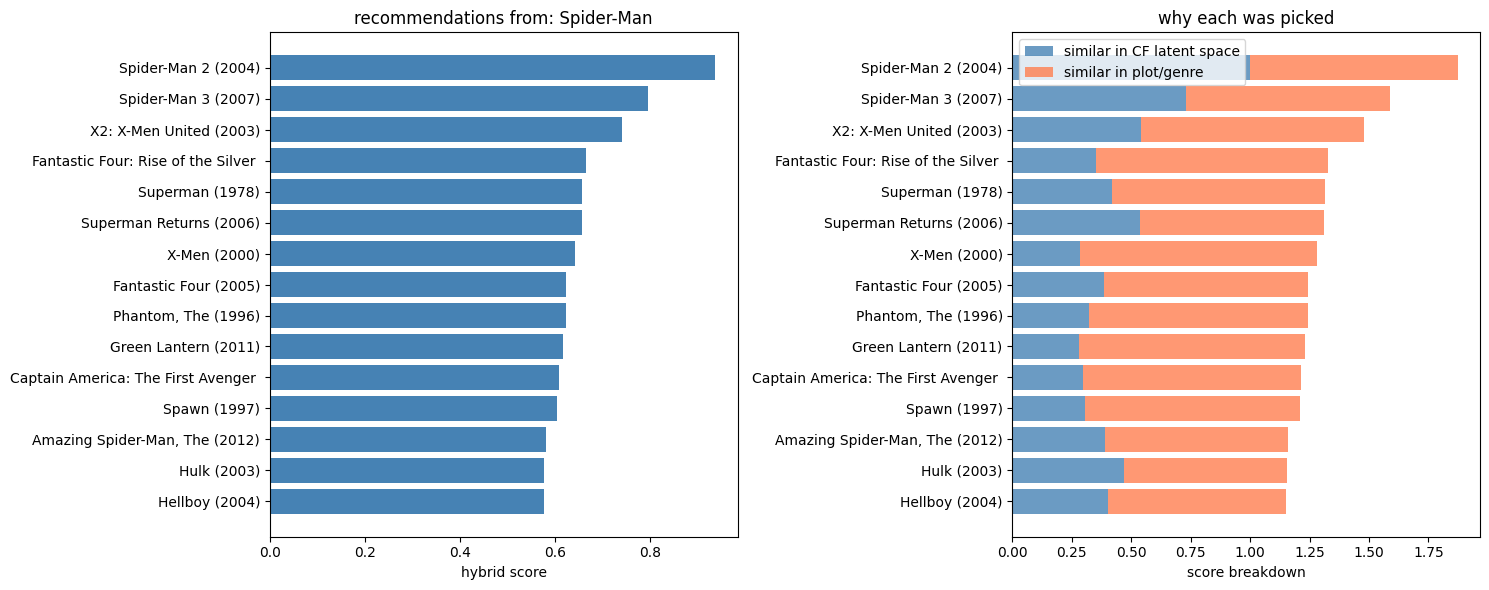

In [13]:
# bar chart of the recommendations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

Short = RecsOne['title'].str[:35]

axes[0].barh(Short[::-1], RecsOne['hybrid_score'][::-1], color='steelblue')
axes[0].set_xlabel('hybrid score')
axes[0].set_title(f"recommendations from: {MOVIE}")

axes[1].barh(Short[::-1], RecsOne['cf_score'][::-1],
             label='similar in CF latent space', color='steelblue', alpha=0.8)
axes[1].barh(Short[::-1], RecsOne['content_score'][::-1],
             left=RecsOne['cf_score'][::-1],
             label='similar in plot/genre', color='coral', alpha=0.8)
axes[1].set_xlabel('score breakdown')
axes[1].set_title('why each was picked')
axes[1].legend()

plt.tight_layout()
plt.show()
